# Cross-Model SAE Feature-Level Gender Bias Experiments

**Goal**: Replicate the GPT-2 SAE male skew / occupation bias decoupling experiment on Pythia-70m-deduped (and potentially OLMo when SAEs become available).

**Key question**: Does the bias–mass entanglement finding from GPT-2 replicate across architectures?

This notebook is config-driven: change `MODEL_KEY` below to run on a different model. All model-specific parameters (SAE release, hook names, layer indices) live in `model_configs.py`.

**Pipeline stages**:
1. Load model + SAE
2. Baseline measurements
3. SAE feature discovery (differential activation)
4. Feature clamping sweep
5. Analysis: Pareto plot, decoupled features
6. Feature characterisation (logit lens, prompt analysis)
7. Test-set evaluation with bootstrap CIs
8. Capability evaluations (PPL, LAMBADA, BLiMP, Winogender, CrowS-Pairs)

In [1]:
# ══════════════════════════════════════════════════════════════════
# SELECT MODEL HERE
# ══════════════════════════════════════════════════════════════════
MODEL_KEY = "gpt2"   # Options: "gpt2", "pythia-70m", "olmo-1b"
N_FEATURE_CANDIDATES = 50  # top-N from each direction in discovery
BIAS_THRESHOLD_PCT = 5     # minimum abs_bias reduction % to count as "bias reducer"
MASS_THRESHOLD_PCT = 5     # maximum |mass change %| for "decoupled" features

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import os
from collections import defaultdict

from transformer_lens import HookedTransformer
from sae_lens import SAE

# Local imports
from model_configs import MODELS, RUNNABLE_MODELS
from data import (
    DEV_OCCUPATIONS, DEV_OCCUPATIONS_MALE, DEV_OCCUPATIONS_FEMALE,
    NEUTRAL_OCCUPATIONS, DEV_TEMPLATES,
    TEST_OCCUPATIONS, TEST_TEMPLATES,
    WINOGENDER_OCCUPATIONS, WINOGENDER_TEMPLATES,
    build_prompts,
)
from metrics import (
    compute_bias_metrics, compute_bias_metrics_with_ci,
    compute_stereotype_amplification,
    get_sae_activations_for_prompts,
    make_sae_feature_clamp_hook, make_multi_feature_clamp_hook,
    compute_ppl, compute_lambada_acc, compute_blimp_acc,
    compute_winogender_male_pct, compute_crows_pairs_score,
)

/orcd/software/core/001/pkg/miniforge/25.11.0-0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Setup: Load Model and SAE

In [3]:
# Validate model selection
assert MODEL_KEY in RUNNABLE_MODELS, (
    f"{MODEL_KEY} not runnable. Available: {list(RUNNABLE_MODELS.keys())}. "
    f"OLMo has no SAE-Lens SAEs yet."
)
cfg = MODELS[MODEL_KEY]
print(f"Model: {cfg['display_name']}")
print(f"  Layers: {cfg['n_layers']}, d_model: {cfg['d_model']}")
print(f"  SAE: {cfg['sae_release']} / {cfg['sae_id']}")
print(f"  Hook: {cfg['hook_name']} (layer {cfg['sae_layer']})")

Model: GPT-2 Small
  Layers: 12, d_model: 768
  SAE: gpt2-small-res-jb / blocks.11.hook_resid_pre
  Hook: blocks.10.hook_resid_post (layer 10)


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Load model
model = HookedTransformer.from_pretrained(cfg["model_id"], device=device)
model.eval()
print(f"Model loaded: {cfg['display_name']}")

Device: cuda


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2102.82it/s]


Loaded pretrained model gpt2 into HookedTransformer
Model loaded: GPT-2 Small


In [5]:
# Load SAE
sae = SAE.from_pretrained(
    release=cfg["sae_release"],
    sae_id=cfg["sae_id"],
    device=device,
)[0]
HOOK_NAME = cfg["hook_name"]
SAE_LAYER = cfg["sae_layer"]
print(f"SAE loaded: {sae.cfg.d_sae} features, d_model={sae.cfg.d_in}")

SAE loaded: 24576 features, d_model=768


/home/ayela/.local/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(
/tmp/ipykernel_719/685252942.py:2: DeprecationWarning: Indexing SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae = SAE.from_pretrained(


In [6]:
# Resolve gender token IDs for this model's tokenizer
male_token_ids = [model.to_single_token(t) for t in cfg["male_token_strings"]]
female_token_ids = [model.to_single_token(t) for t in cfg["female_token_strings"]]
print(f"Male token IDs:   {male_token_ids}")
print(f"Female token IDs: {female_token_ids}")

# Verify tokens round-trip correctly
for tid, s in zip(male_token_ids, cfg["male_token_strings"]):
    decoded = model.to_string([tid])
    assert decoded == s, f"Token mismatch: {s!r} -> {tid} -> {decoded!r}"
print("Token verification passed.")

Male token IDs:   [258, 339, 1544, 679]
Female token IDs: [7091, 673, 3347, 1375]
Token verification passed.


## 1. Build Prompts

In [7]:
dev_prompts = build_prompts(DEV_OCCUPATIONS, DEV_TEMPLATES)
neutral_prompts = build_prompts(NEUTRAL_OCCUPATIONS, DEV_TEMPLATES)
test_prompts = build_prompts(TEST_OCCUPATIONS, TEST_TEMPLATES)
print(f"Dev prompts: {len(dev_prompts)}, Neutral: {len(neutral_prompts)}, Test: {len(test_prompts)}")

Dev prompts: 200, Neutral: 50, Test: 250


## 2. Baseline Measurements

In [8]:
print("Computing baseline metrics...")
baseline = compute_bias_metrics(dev_prompts, model, male_token_ids, female_token_ids)
baseline_amp = compute_stereotype_amplification(
    dev_prompts, DEV_OCCUPATIONS, DEV_TEMPLATES, model, male_token_ids, female_token_ids
)
baseline_neutral = compute_bias_metrics(neutral_prompts, model, male_token_ids, female_token_ids)

print(f"Baseline abs_bias:      {baseline['abs_bias']:.4f}")
print(f"Baseline signed_bias:   {baseline['signed_bias']:.4f}")
print(f"Baseline gender_mass:   {baseline['gender_mass']:.4f}")
print(f"Baseline amplification: {baseline_amp['amplification']:.4f}")
print(f"Baseline neutral skew:  {baseline_neutral['signed_bias']:.4f}")

Computing baseline metrics...
Baseline abs_bias:      0.1179
Baseline signed_bias:   0.0282
Baseline gender_mass:   0.2073
Baseline amplification: 0.1240
Baseline neutral skew:  0.1257


## 3. SAE Feature Discovery

In [9]:
print("Collecting SAE feature activations on dev prompts...")
sae_acts = get_sae_activations_for_prompts(dev_prompts, model, sae, layer=SAE_LAYER)
print(f"SAE activations shape: {sae_acts.shape}")

SAE activations shape: torch.Size([200, 24576])


In [10]:
# Differential activation: male-occ vs female-occ prompts
n_templates = len(DEV_TEMPLATES)
n_male_occ = len(DEV_OCCUPATIONS_MALE)

male_occ_indices = list(range(0, n_male_occ * n_templates))
female_occ_indices = list(range(n_male_occ * n_templates, len(dev_prompts)))

male_occ_acts = sae_acts[male_occ_indices].mean(dim=0)
female_occ_acts = sae_acts[female_occ_indices].mean(dim=0)
diff_activation = male_occ_acts - female_occ_acts
overall_activation = sae_acts.mean(dim=0)

# Top candidates
top_male_biased = torch.argsort(diff_activation, descending=True)[:N_FEATURE_CANDIDATES]
top_female_biased = torch.argsort(diff_activation, descending=False)[:N_FEATURE_CANDIDATES]

# Include known features if any (model-specific)
known_fids = [v for v in cfg["known_features"].values() if v is not None]
all_candidate_ids = list(set(
    top_male_biased.tolist() + top_female_biased.tolist() + known_fids
))

print(f"\nTop male-biased features:")
for fid in top_male_biased[:10].tolist():
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")

print(f"\nTop female-biased features:")
for fid in top_female_biased[:10].tolist():
    print(f"  F{fid}: diff={diff_activation[fid]:.4f}, overall={overall_activation[fid]:.4f}")

print(f"\nTotal candidate features: {len(all_candidate_ids)}")


Top male-biased features:
  F837: diff=2.6426, overall=1.9059
  F18624: diff=2.1607, overall=15.6678
  F7055: diff=1.8226, overall=11.8481
  F2376: diff=1.7773, overall=2.2466
  F14652: diff=1.7647, overall=1.2840
  F7370: diff=1.7642, overall=2.7022
  F9515: diff=1.6646, overall=1.9883
  F15241: diff=1.3730, overall=0.6865
  F15346: diff=1.3319, overall=13.9188
  F18892: diff=1.2679, overall=0.6467

Top female-biased features:
  F23772: diff=-3.4370, overall=1.7185
  F4077: diff=-3.2704, overall=1.6501
  F17632: diff=-2.4240, overall=1.3139
  F8630: diff=-2.3646, overall=1.4769
  F13625: diff=-2.1951, overall=1.0976
  F5490: diff=-1.6820, overall=3.4150
  F17442: diff=-1.6243, overall=2.0671
  F15242: diff=-1.4784, overall=7.9118
  F11223: diff=-1.3939, overall=0.6970
  F9293: diff=-1.2892, overall=0.6446

Total candidate features: 102


## 4. Feature Clamping Sweep

In [11]:
print("Feature clamping sweep (clamp each candidate to zero, measure bias + mass)...")
feature_results = []

for fid in tqdm(all_candidate_ids, desc="Feature clamping sweep"):
    hook_fn = make_sae_feature_clamp_hook(sae, fid, scale=0.0)

    metrics = compute_bias_metrics(
        dev_prompts, model, male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )
    amp_metrics = compute_stereotype_amplification(
        dev_prompts, DEV_OCCUPATIONS, DEV_TEMPLATES, model,
        male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=HOOK_NAME,
    )

    feature_results.append({
        "feature_id": fid,
        "abs_bias": metrics["abs_bias"],
        "signed_bias": metrics["signed_bias"],
        "gender_mass": metrics["gender_mass"],
        "amplification": amp_metrics["amplification"],
        "mean_signed": amp_metrics["mean_signed"],
        "abs_bias_reduction_pct": (baseline["abs_bias"] - metrics["abs_bias"]) / baseline["abs_bias"] * 100,
        "signed_bias_change": metrics["signed_bias"] - baseline["signed_bias"],
        "gender_mass_change_pct": (metrics["gender_mass"] - baseline["gender_mass"]) / baseline["gender_mass"] * 100,
        "amp_reduction_pct": (baseline_amp["amplification"] - amp_metrics["amplification"]) / baseline_amp["amplification"] * 100,
        "diff_activation": diff_activation[fid].item(),
    })

df = pd.DataFrame(feature_results)
print(f"Sweep complete: {len(df)} features evaluated.")

Feature clamping sweep (clamp each candidate to zero, measure bias + mass)...


Feature clamping sweep: 100%|██████████| 102/102 [04:56<00:00,  2.90s/it]

Sweep complete: 102 features evaluated.


## 5. Analysis: Selectivity, Pareto Plot, Decoupled Features

In [12]:
df["selectivity"] = df["abs_bias_reduction_pct"] / (df["gender_mass_change_pct"].abs() + 1)

bias_reducers = df[df["abs_bias_reduction_pct"] > BIAS_THRESHOLD_PCT].sort_values("selectivity", ascending=False)
print(f"Features with >{BIAS_THRESHOLD_PCT}% abs bias reduction: {len(bias_reducers)}")
if len(bias_reducers) > 0:
    print(bias_reducers[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                          "gender_mass_change_pct", "amp_reduction_pct", "selectivity"]].head(20).to_string())

decoupled = df[
    (df["abs_bias_reduction_pct"] > BIAS_THRESHOLD_PCT) &
    (df["gender_mass_change_pct"].abs() < MASS_THRESHOLD_PCT)
]
print(f"\nDecoupled features (>{BIAS_THRESHOLD_PCT}% bias red, <{MASS_THRESHOLD_PCT}% mass change): {len(decoupled)}")
if len(decoupled) > 0:
    print("*** POSITIVE RESULT: Found features that decouple bias from mass! ***")
    print(decoupled[["feature_id", "abs_bias_reduction_pct", "signed_bias_change",
                      "gender_mass_change_pct", "selectivity"]].to_string())
else:
    print("Negative result: No features found that decouple bias from gender mass suppression.")
    print("This strengthens the claim that bias and gender encoding are fundamentally entangled.")

Features with >5% abs bias reduction: 7
    feature_id  abs_bias_reduction_pct  signed_bias_change  gender_mass_change_pct  amp_reduction_pct  selectivity
42       23772               11.188159            0.013196                0.141312          12.547879     9.802896
94        4077               19.860372            0.024618               -1.875920          21.916742     6.905745
56         837                6.921459           -0.009661               -1.726694           6.238206     2.538407
0         1024                6.422452           -0.003744               -6.061853           6.009020     0.909457
45        4846                7.553775           -0.007432               -8.745517           7.522977     0.775103
73       15242               10.132300           -0.010299              -13.047816           9.175282     0.721272
31       19111                5.476334           -0.002270               -7.063856           5.077999     0.679121

Decoupled features (>5% bias red, <5% m

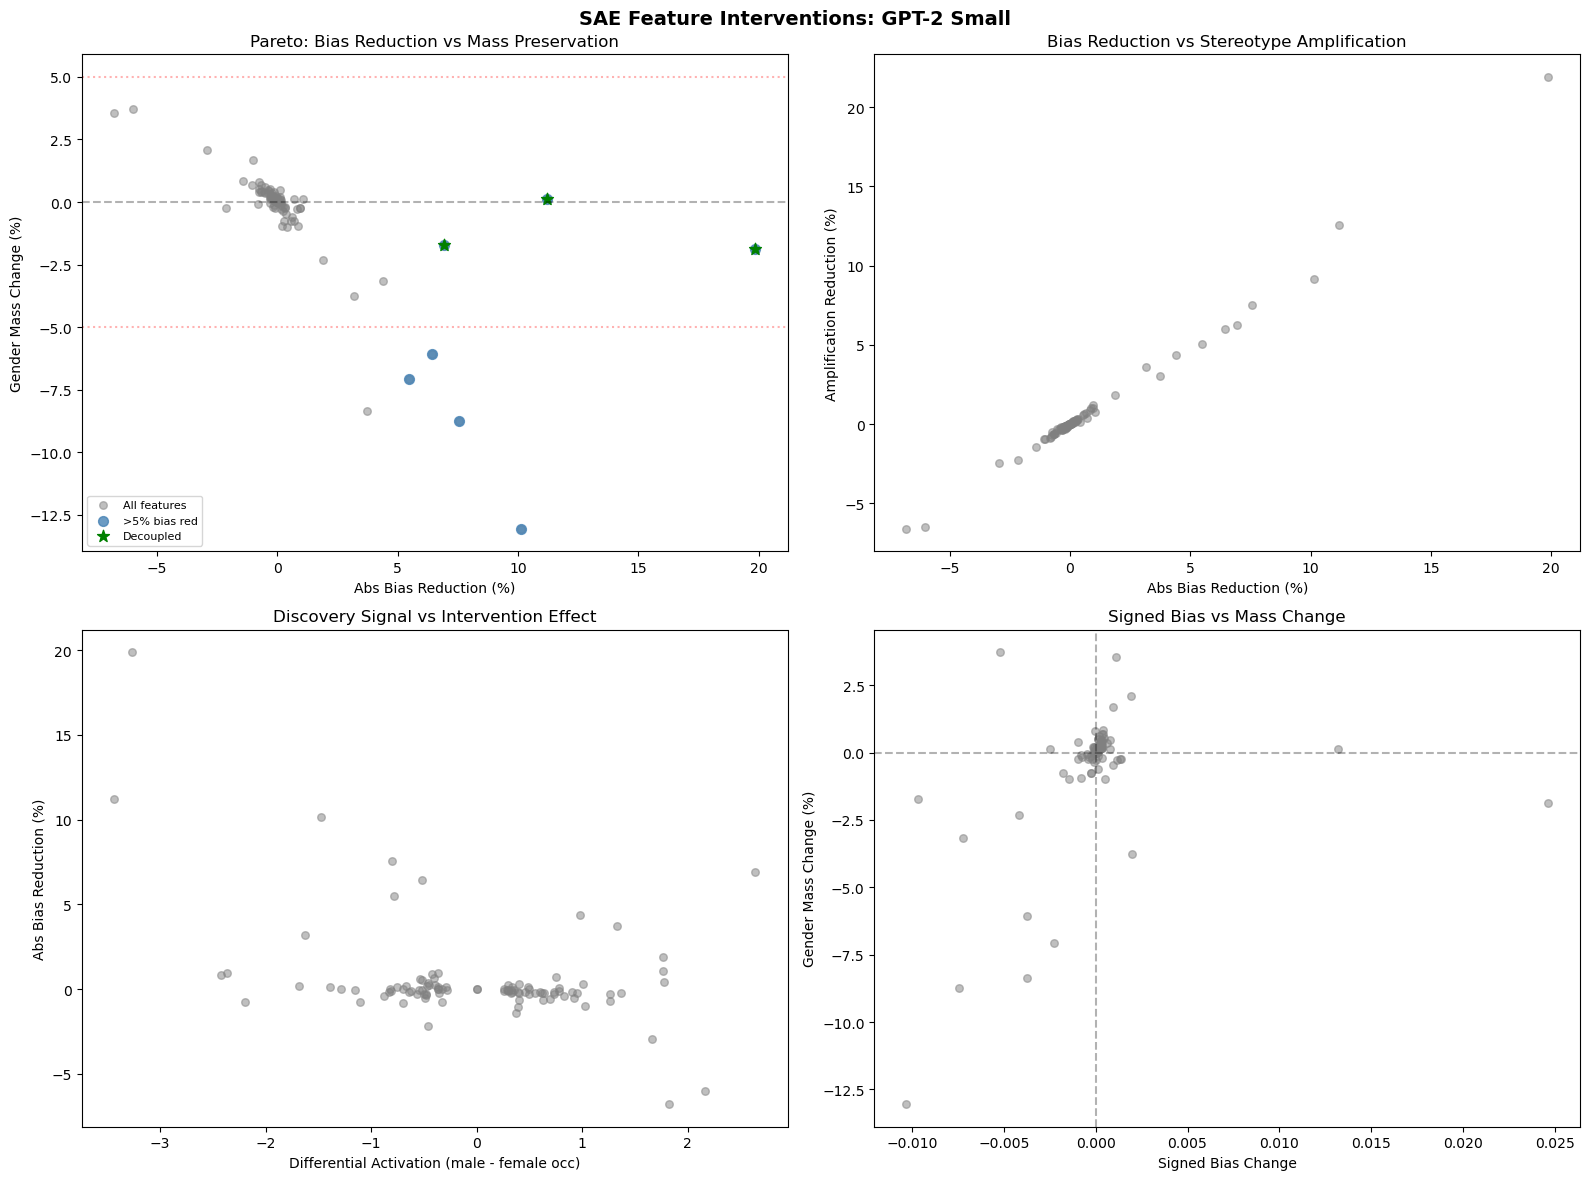

Saved: results_gpt2_pareto.png


In [13]:
# Pareto plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"SAE Feature Interventions: {cfg['display_name']}",
             fontsize=14, fontweight="bold")

ax = axes[0, 0]
ax.scatter(df["abs_bias_reduction_pct"], df["gender_mass_change_pct"],
           alpha=0.5, s=30, c="gray", label="All features")
if len(bias_reducers) > 0:
    ax.scatter(bias_reducers["abs_bias_reduction_pct"], bias_reducers["gender_mass_change_pct"],
               alpha=0.8, s=50, c="steelblue", label=f">{BIAS_THRESHOLD_PCT}% bias red")
if len(decoupled) > 0:
    ax.scatter(decoupled["abs_bias_reduction_pct"], decoupled["gender_mass_change_pct"],
               alpha=1.0, s=80, c="green", marker="*", label="Decoupled")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax.axhline(y=-MASS_THRESHOLD_PCT, color="red", linestyle=":", alpha=0.3)
ax.axhline(y=MASS_THRESHOLD_PCT, color="red", linestyle=":", alpha=0.3)
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Pareto: Bias Reduction vs Mass Preservation")
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.scatter(df["abs_bias_reduction_pct"], df["amp_reduction_pct"],
           alpha=0.5, s=30, c="gray")
ax.set_xlabel("Abs Bias Reduction (%)")
ax.set_ylabel("Amplification Reduction (%)")
ax.set_title("Bias Reduction vs Stereotype Amplification")

ax = axes[1, 0]
ax.scatter(df["diff_activation"], df["abs_bias_reduction_pct"],
           alpha=0.5, s=30, c="gray")
ax.set_xlabel("Differential Activation (male - female occ)")
ax.set_ylabel("Abs Bias Reduction (%)")
ax.set_title("Discovery Signal vs Intervention Effect")

ax = axes[1, 1]
ax.scatter(df["signed_bias_change"], df["gender_mass_change_pct"],
           alpha=0.5, s=30, c="gray")
ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax.axvline(x=0, color="black", linestyle="--", alpha=0.3)
ax.set_xlabel("Signed Bias Change")
ax.set_ylabel("Gender Mass Change (%)")
ax.set_title("Signed Bias vs Mass Change")

plt.tight_layout()
plt.savefig(f"results_{cfg['name']}_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: results_{cfg['name']}_pareto.png")

## 6. Feature Characterisation (Logit Lens)

In [14]:
# Characterise top decoupled features (if any) and top bias reducers
features_to_check = {}
if len(decoupled) > 0:
    for _, row in decoupled.head(5).iterrows():
        fid = int(row["feature_id"])
        features_to_check[f"F{fid} (decoupled)"] = fid
if len(bias_reducers) > 0:
    for _, row in bias_reducers.head(3).iterrows():
        fid = int(row["feature_id"])
        if fid not in features_to_check.values():
            features_to_check[f"F{fid} (bias reducer)"] = fid
# Add known features
for name, fid in cfg["known_features"].items():
    features_to_check[name] = fid

print(f"Characterising {len(features_to_check)} features...")
for name, fid in features_to_check.items():
    print(f"\n--- {name} (feature {fid}) ---")

    # Logit lens
    feature_dir = sae.W_dec[fid]
    logit_contributions = model.W_U.T @ feature_dir

    top_pos = torch.topk(logit_contributions, k=15)
    top_neg = torch.topk(logit_contributions, k=15, largest=False)

    print("  Top PROMOTED tokens:")
    for i in range(15):
        tok = model.to_string([top_pos.indices[i].item()])
        print(f"    {tok!r:>15s}  {top_pos.values[i].item():+.3f}")

    print("  Top SUPPRESSED tokens:")
    for i in range(15):
        tok = model.to_string([top_neg.indices[i].item()])
        print(f"    {tok!r:>15s}  {top_neg.values[i].item():+.3f}")

    # Prompt activations
    feature_acts = sae_acts[:, fid]
    top_prompt_idx = torch.topk(feature_acts, k=min(10, len(dev_prompts))).indices
    print("  Top ACTIVATING prompts:")
    for idx in top_prompt_idx:
        print(f"    [{feature_acts[idx]:.3f}] {dev_prompts[idx]}")

    # Gender specificity
    male_mean = feature_acts[:n_male_occ * n_templates].mean().item()
    female_mean = feature_acts[n_male_occ * n_templates:].mean().item()
    print(f"  Male-occ mean:   {male_mean:.4f}")
    print(f"  Female-occ mean: {female_mean:.4f}")
    print(f"  Differential:    {male_mean - female_mean:.4f}")

Characterising 5 features...

--- F23772 (decoupled) (feature 23772) ---
  Top PROMOTED tokens:
         ' herself'  +2.154
             ' her'  +1.829
             ' she'  +1.575
            ' hers'  +1.565
              'She'  +1.403
             ' She'  +1.355
             ' SHE'  +1.322
              'Her'  +1.251
              'she'  +1.235
             ' HER'  +1.194
         ' husband'  +1.152
       ' boyfriend'  +1.136
             ' Her'  +1.125
       ' pregnancy'  +1.118
          ' bikini'  +1.113
  Top SUPPRESSED tokens:
                '版'  -0.597
            'espie'  -0.595
             'uden'  -0.567
                'ワ'  -0.539
              'sov'  -0.534
            'opoly'  -0.533
              'yip'  -0.532
    ' Transactions'  -0.527
          'Players'  -0.524
                '代'  -0.524
          'players'  -0.518
                '�'  -0.511
         'Magikarp'  -0.511
             'atos'  -0.506
    ' Infrastructure'  -0.495
  Top ACTIVATING prompts:
    [8.695]

## 7. Build Interventions for Full Evaluation

Based on the discovery results, build intervention configs.
If decoupled features were found, test them individually and in combinations.
If not, test the top bias reducers anyway (to characterise the mass cost).

In [15]:
# Auto-build interventions from discovery results
INTERVENTIONS = {"Baseline": None}

# Add top individual features
top_features_for_eval = []
if len(decoupled) > 0:
    for _, row in decoupled.head(3).iterrows():
        fid = int(row["feature_id"])
        INTERVENTIONS[f"F{fid}"] = {fid: 0.0}
        top_features_for_eval.append(fid)
elif len(bias_reducers) > 0:
    for _, row in bias_reducers.head(3).iterrows():
        fid = int(row["feature_id"])
        INTERVENTIONS[f"F{fid}"] = {fid: 0.0}
        top_features_for_eval.append(fid)

# Add combinations if we have 2+ features
if len(top_features_for_eval) >= 2:
    combo_name = " + ".join(f"F{f}" for f in top_features_for_eval[:2])
    INTERVENTIONS[combo_name] = {f: 0.0 for f in top_features_for_eval[:2]}
if len(top_features_for_eval) >= 3:
    INTERVENTIONS["All three"] = {f: 0.0 for f in top_features_for_eval[:3]}
    # Half-scale variant
    INTERVENTIONS[f"F{top_features_for_eval[0]} (half) + F{top_features_for_eval[1]}"] = {
        top_features_for_eval[0]: 0.5, top_features_for_eval[1]: 0.0
    }

print("Interventions to evaluate:")
for name, spec in INTERVENTIONS.items():
    print(f"  {name}: {spec}")

Interventions to evaluate:
  Baseline: None
  F23772: {23772: 0.0}
  F837: {837: 0.0}
  F4077: {4077: 0.0}
  F23772 + F837: {23772: 0.0, 837: 0.0}
  All three: {23772: 0.0, 837: 0.0, 4077: 0.0}
  F23772 (half) + F837: {23772: 0.5, 837: 0.0}


In [16]:
def get_hook_for_intervention(intervention_dict):
    """Return (hook_fn, hook_name) for an intervention spec."""
    if intervention_dict is None:
        return None, None
    if len(intervention_dict) == 1:
        fid, scale = list(intervention_dict.items())[0]
        return make_sae_feature_clamp_hook(sae, fid, scale=scale), HOOK_NAME
    else:
        return make_multi_feature_clamp_hook(sae, intervention_dict), HOOK_NAME

## 8. Test-Set Bias Metrics + Bootstrap CIs

In [17]:
print("Test-set evaluation with bootstrap CIs...")
test_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  Evaluating: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    result = compute_bias_metrics_with_ci(
        test_prompts, model, male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=hook_name,
    )
    test_results[name] = result
    print(f"    abs_bias={result['abs_bias']:.4f} [{result['abs_bias_ci'][0]:.4f}, {result['abs_bias_ci'][1]:.4f}]")
    print(f"    signed ={result['signed_bias']:.4f}, mass={result['gender_mass']:.4f}")

Test-set evaluation with bootstrap CIs...
  Evaluating: Baseline...


    abs_bias=0.0693 [0.0607, 0.0786]
    signed =0.0689, mass=0.1604
  Evaluating: F23772...


    abs_bias=0.0703 [0.0617, 0.0796]
    signed =0.0699, mass=0.1603
  Evaluating: F837...


    abs_bias=0.0614 [0.0539, 0.0697]
    signed =0.0610, mass=0.1585
  Evaluating: F4077...


    abs_bias=0.0729 [0.0636, 0.0831]
    signed =0.0726, mass=0.1597
  Evaluating: F23772 + F837...


    abs_bias=0.0625 [0.0549, 0.0709]
    signed =0.0621, mass=0.1584
  Evaluating: All three...


    abs_bias=0.0665 [0.0581, 0.0758]
    signed =0.0661, mass=0.1577
  Evaluating: F23772 (half) + F837...


    abs_bias=0.0620 [0.0544, 0.0703]
    signed =0.0616, mass=0.1584


## 9. Capability Evaluations

In [18]:
from datasets import load_dataset

# WikiText-103 PPL
print("Loading WikiText-103...")
wikitext = load_dataset("wikitext", "wikitext-103-raw-v1", split="validation")
wiki_sentences = [line for line in wikitext["text"] if len(line.strip()) > 50][:1000]
print(f"Using {len(wiki_sentences)} sentences")

ppl_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  PPL: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    ppl = compute_ppl(wiki_sentences, model, hook_fn=hook_fn, hook_name=hook_name)
    ppl_results[name] = ppl
    change = (ppl - ppl_results.get("Baseline", ppl)) / ppl_results.get("Baseline", ppl) * 100
    print(f"    PPL: {ppl:.1f} ({change:+.1f}%)")

Loading WikiText-103...
Using 1000 sentences
  PPL: Baseline...


    PPL: 48.8 (+0.0%)
  PPL: F23772...


    PPL: 48.8 (+0.0%)
  PPL: F837...


    PPL: 48.8 (+0.0%)
  PPL: F4077...


    PPL: 48.8 (+0.0%)
  PPL: F23772 + F837...


    PPL: 48.8 (+0.0%)
  PPL: All three...


    PPL: 48.8 (+0.0%)
  PPL: F23772 (half) + F837...


    PPL: 48.8 (+0.0%)


In [19]:
# LAMBADA
print("Loading LAMBADA...")
lambada = load_dataset("lambada", split="test")
lambada_examples = list(lambada)[:500]
print(f"Using {len(lambada_examples)} examples")

lambada_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  LAMBADA: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    acc = compute_lambada_acc(lambada_examples, model, hook_fn=hook_fn, hook_name=hook_name)
    lambada_results[name] = acc
    print(f"    Accuracy: {acc:.1%}")

Loading LAMBADA...
Using 500 examples
  LAMBADA: Baseline...


    Accuracy: 15.0%
  LAMBADA: F23772...


    Accuracy: 15.0%
  LAMBADA: F837...


    Accuracy: 15.0%
  LAMBADA: F4077...


    Accuracy: 15.0%
  LAMBADA: F23772 + F837...


    Accuracy: 15.0%
  LAMBADA: All three...


    Accuracy: 15.0%
  LAMBADA: F23772 (half) + F837...


    Accuracy: 15.0%


In [20]:
# BLiMP
blimp_tasks = ["anaphor_gender_agreement", "irregular_past_participle_adjectives"]
blimp_data = {}
for task in blimp_tasks:
    try:
        ds = load_dataset("blimp", task, split="train", trust_remote_code=True)
        blimp_data[task] = list(ds)[:200]
        print(f"  Loaded {len(blimp_data[task])} {task} examples")
    except Exception as e:
        print(f"  Failed to load {task}: {e}")

blimp_results = {}
if blimp_data:
    for name, intervention in INTERVENTIONS.items():
        print(f"  BLiMP: {name}...")
        hook_fn, hook_name = get_hook_for_intervention(intervention)
        task_accs = {}
        for task, examples in blimp_data.items():
            acc = compute_blimp_acc(examples, model, hook_fn=hook_fn, hook_name=hook_name)
            task_accs[task] = acc
        mean_acc = np.mean(list(task_accs.values()))
        blimp_results[name] = {"per_task": task_accs, "mean": mean_acc}
        print(f"    Mean acc: {mean_acc:.1%}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'blimp' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'blimp' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


  Loaded 200 anaphor_gender_agreement examples
  Loaded 200 irregular_past_participle_adjectives examples
  BLiMP: Baseline...


    Mean acc: 99.5%
  BLiMP: F23772...


    Mean acc: 99.5%
  BLiMP: F837...


    Mean acc: 99.5%
  BLiMP: F4077...


    Mean acc: 99.5%
  BLiMP: F23772 + F837...


    Mean acc: 99.5%
  BLiMP: All three...


    Mean acc: 99.5%
  BLiMP: F23772 (half) + F837...


    Mean acc: 99.5%


In [21]:
# Winogender
print("Winogender evaluation...")
winogender_results = {}
for name, intervention in INTERVENTIONS.items():
    print(f"  Winogender: {name}...")
    hook_fn, hook_name = get_hook_for_intervention(intervention)
    male_pct, per_occ = compute_winogender_male_pct(
        WINOGENDER_OCCUPATIONS, WINOGENDER_TEMPLATES, model,
        male_token_ids, female_token_ids,
        hook_fn=hook_fn, hook_name=hook_name,
    )
    winogender_results[name] = {"male_pct": male_pct, "per_occ": per_occ}
    print(f"    Male %: {male_pct:.1%}")

Winogender evaluation...
  Winogender: Baseline...
    Male %: 80.5%
  Winogender: F23772...
    Male %: 81.5%
  Winogender: F837...
    Male %: 78.0%
  Winogender: F4077...
    Male %: 81.5%
  Winogender: F23772 + F837...
    Male %: 80.5%
  Winogender: All three...
    Male %: 88.5%
  Winogender: F23772 (half) + F837...
    Male %: 79.5%


In [25]:
# CrowS-Pairs
print("Loading CrowS-Pairs...")
gender_pairs = []
try:
    crows = load_dataset("nyu-mll/crows_pairs", split="test")
    gender_pairs = [ex for ex in crows if ex.get("bias_type", "") == "gender"]
    if len(gender_pairs) == 0:
        gender_pairs = [ex for ex in crows if ex.get("bias_type", -1) == 0]
    print(f"  Loaded {len(gender_pairs)} gender pairs from HF Hub")
except Exception as e:
    print(f"  HF Hub failed ({e}), trying GitHub CSV fallback...")
    try:
        crows_url = "https://raw.githubusercontent.com/nyu-mll/crows-pairs/master/data/crows_pairs_anonymized.csv"
        crows_df = pd.read_csv(crows_url)
        gender_rows = crows_df[crows_df["bias_type"] == "gender"]
        gender_pairs = [
            {"sent_more": row["sent_more"], "sent_less": row["sent_less"]}
            for _, row in gender_rows.iterrows()
        ]
        print(f"  Loaded {len(gender_pairs)} gender pairs from GitHub CSV")
    except Exception as e2:
        print(f"  GitHub CSV also failed: {e2}")

crows_results = {}
if gender_pairs:
    for name, intervention in INTERVENTIONS.items():
        print(f"  CrowS: {name}...")
        hook_fn, hook_name = get_hook_for_intervention(intervention)
        score = compute_crows_pairs_score(gender_pairs, model, hook_fn=hook_fn, hook_name=hook_name)
        crows_results[name] = score
        print(f"    Stereotype preference: {score:.1%}")

Loading CrowS-Pairs...
  HF Hub failed (Dataset scripts are no longer supported, but found crows_pairs.py), trying GitHub CSV fallback...
  Loaded 262 gender pairs from GitHub CSV
  CrowS: Baseline...


    Stereotype preference: 60.7%
  CrowS: F23772...


    Stereotype preference: 60.7%
  CrowS: F837...


    Stereotype preference: 60.7%
  CrowS: F4077...


    Stereotype preference: 60.7%
  CrowS: F23772 + F837...


    Stereotype preference: 60.7%
  CrowS: All three...


    Stereotype preference: 60.7%
  CrowS: F23772 (half) + F837...


    Stereotype preference: 60.7%


## 10. Summary Table

In [26]:
baseline_abs = test_results["Baseline"]["abs_bias"]
rows = []
for name in INTERVENTIONS:
    tr = test_results[name]
    row = {
        "Intervention": name,
        "Abs Bias": f"{tr['abs_bias']:.4f} [{tr['abs_bias_ci'][0]:.4f}, {tr['abs_bias_ci'][1]:.4f}]",
        "Abs Bias Red %": f"{(baseline_abs - tr['abs_bias']) / baseline_abs * 100:.1f}%" if name != "Baseline" else "—",
        "Signed Bias": f"{tr['signed_bias']:.4f} [{tr['signed_bias_ci'][0]:.4f}, {tr['signed_bias_ci'][1]:.4f}]",
        "Gender Mass": f"{tr['gender_mass']:.4f} [{tr['gender_mass_ci'][0]:.4f}, {tr['gender_mass_ci'][1]:.4f}]",
        "PPL": f"{ppl_results.get(name, 'N/A')}",
        "LAMBADA": f"{lambada_results.get(name, 'N/A')}",
        "BLiMP": f"{blimp_results.get(name, {}).get('mean', 'N/A')}",
        "Wino Male%": f"{winogender_results.get(name, {}).get('male_pct', 'N/A')}",
        "CrowS": f"{crows_results.get(name, 'N/A')}",
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

        Intervention                Abs Bias Abs Bias Red %             Signed Bias             Gender Mass              PPL LAMBADA BLiMP Wino Male%              CrowS
            Baseline 0.0693 [0.0607, 0.0786]              — 0.0689 [0.0603, 0.0782] 0.1604 [0.1446, 0.1770] 48.8208432014079    0.15 0.995      0.805 0.6068702290076335
              F23772 0.0703 [0.0617, 0.0796]          -1.5% 0.0699 [0.0613, 0.0793] 0.1603 [0.1445, 0.1768] 48.8208432014079    0.15 0.995      0.815 0.6068702290076335
                F837 0.0614 [0.0539, 0.0697]          11.3% 0.0610 [0.0534, 0.0694] 0.1585 [0.1428, 0.1751] 48.8208432014079    0.15 0.995       0.78 0.6068702290076335
               F4077 0.0729 [0.0636, 0.0831]          -5.2% 0.0726 [0.0633, 0.0828] 0.1597 [0.1442, 0.1762] 48.8208432014079    0.15 0.995      0.815 0.6068702290076335
       F23772 + F837 0.0625 [0.0549, 0.0709]           9.8% 0.0621 [0.0544, 0.0705] 0.1584 [0.1427, 0.1750] 48.8208432014079    0.15 0.995      0.805 0.606

## 11. Save Results

In [27]:
results_dir = f"results/{cfg['name']}_sae_male_skew"
os.makedirs(results_dir, exist_ok=True)

# Save sweep results
df.to_csv(f"{results_dir}/feature_sweep.csv", index=False)

# Save all eval results
all_results = {
    "model": cfg["name"],
    "model_display": cfg["display_name"],
    "sae_release": cfg["sae_release"],
    "sae_id": cfg["sae_id"],
    "test_bias": {name: {
        "abs_bias": r["abs_bias"],
        "abs_bias_ci": r["abs_bias_ci"],
        "signed_bias": r["signed_bias"],
        "signed_bias_ci": r["signed_bias_ci"],
        "gender_mass": r["gender_mass"],
        "gender_mass_ci": r["gender_mass_ci"],
    } for name, r in test_results.items()},
    "ppl": ppl_results,
    "lambada": lambada_results,
    "blimp": {k: v["per_task"] for k, v in blimp_results.items()} if blimp_results else {},
    "winogender": {k: v["male_pct"] for k, v in winogender_results.items()},
    "crows_pairs": crows_results,
    "interventions": {k: v for k, v in INTERVENTIONS.items()},
    "n_decoupled_features": len(decoupled),
    "n_bias_reducers": len(bias_reducers),
}

with open(f"{results_dir}/full_results.json", "w") as f:
    json.dump(all_results, f, indent=2, default=float)

summary_df.to_csv(f"{results_dir}/summary_table.csv", index=False)

print(f"\nAll results saved to {results_dir}/")
print(f"  feature_sweep.csv    — per-feature clamping results")
print(f"  full_results.json    — all evaluation metrics")
print(f"  summary_table.csv    — summary table")


All results saved to results/gpt2_sae_male_skew/
  feature_sweep.csv    — per-feature clamping results
  full_results.json    — all evaluation metrics
  summary_table.csv    — summary table
